In [28]:
import os
import zipfile
from dotenv import load_dotenv
    
load_dotenv()

DATA_DIR = os.getenv("DATA_DIR")
ITEM = "diamond_sword"

PACKS_DIR = os.path.join(DATA_DIR, "packs")
ITEM_DIR = os.path.join(DATA_DIR, ITEM)
TARGET_SUFFIX = "assets/minecraft/textures/item/"+ITEM+".png"

print(ITEM_DIR)
print(PACKS_DIR)


data/diamond_sword
data/packs


Extracts `ITEM` from all texurepacks

In [43]:
ctr = 0

os.makedirs(ITEM_DIR, exist_ok=True)

for file in os.listdir(PACKS_DIR):
    if not file.endswith(".zip"):
        continue

    zip_path = os.path.join(PACKS_DIR, file)
    with zipfile.ZipFile(zip_path, 'r') as zr:
        if TARGET_SUFFIX in zr.namelist():
            # Read the bytes and write straight to the final path
            new_path = os.path.join(ITEM_DIR, f"{ITEM}_{ctr}.png")
            with zr.open(TARGET_SUFFIX) as src, open(new_path, "wb") as dst:
                dst.write(src.read())
            ctr += 1


Resizing Item to (32,32)

In [44]:
import os
from PIL import Image

TARGET_SIZE = (32, 32)

def process_item(path: str, filename: str) -> None:
    img = Image.open(path)

    if img.size[0] != img.size[1]:
        print(f"[REMOVED] {filename}: not square {img.size}")
        os.remove(path)
        return

    if img.size != TARGET_SIZE:
        print(f"[RESIZED] {filename}: {img.size} -> {TARGET_SIZE}")
        img = img.resize(TARGET_SIZE, Image.Resampling.LANCZOS)
        img.save(path)


for sword in os.listdir(ITEM_DIR):
    if sword.endswith(".png"):
        process_item(os.path.join(ITEM_DIR, sword), sword)

[RESIZED] diamond_sword_4.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_45.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_51.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_7.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_6.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_56.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_2.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_57.png: (64, 64) -> (32, 32)
[RESIZED] diamond_sword_55.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_41.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_1.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_0.png: (128, 128) -> (32, 32)
[REMOVED] diamond_sword_26.png: not square (32, 320)
[RESIZED] diamond_sword_32.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_18.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_19.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_21.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_36.png: (16, 16) -> (32, 32)
[RESIZED] diamond_sword_22.png: (16, 16) -> (32, 3

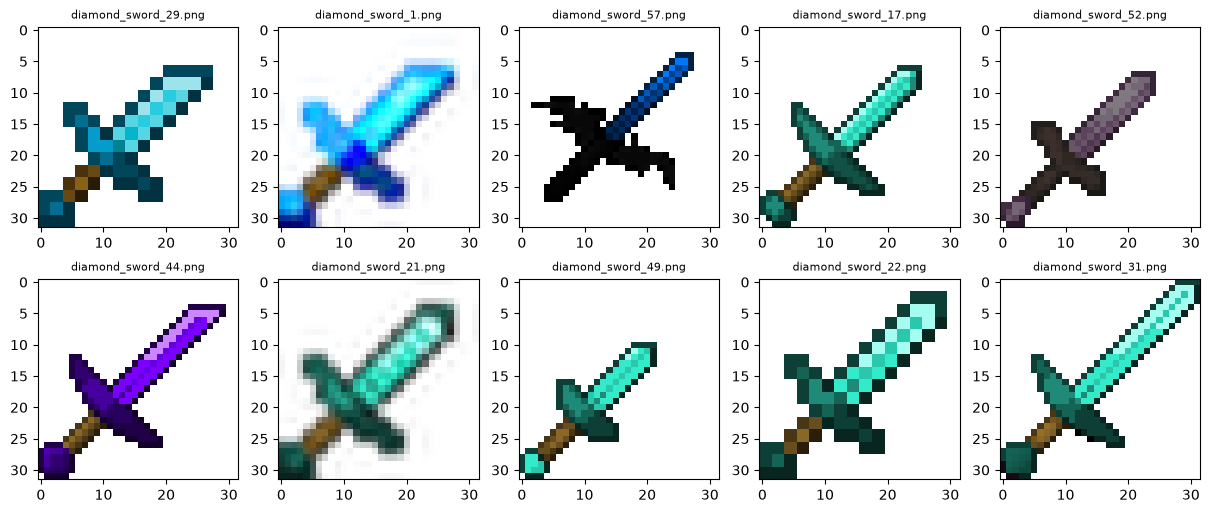

In [56]:
import random
import matplotlib.pyplot as plt

sword_files = [f for f in os.listdir(ITEM_DIR) if f.endswith(".png")]
sample = random.sample(sword_files, min(10, len(sword_files)))

cols = 5
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))
axes = axes.flatten()

for i, sword in enumerate(sample):
    img = Image.open(os.path.join(ITEM_DIR, sword))
    axes[i].imshow(img)
    axes[i].set_title(sword, fontsize=8)



plt.show()